# Policy Optimization: The Lemma, the Gradient, and the Clipped Surrogate

The lecture makes three claims that are checkable to machine precision on a
small MDP:

1. the performance difference lemma is an **identity**, for any two policies;
2. the policy gradient is its **first-order limit**, so it must agree with a
   finite difference of $J$;
3. freezing the occupancy gives a surrogate that is accurate for small steps
   and **wrong** for large ones --- which is what clipping is for.

Everything below is solved exactly with linear algebra, so any disagreement is
a real disagreement rather than sampling noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26521
rng = np.random.default_rng(SEED)

# Three states, two actions. P[s, a, s'] and R[s, a] are fixed by hand so the
# example is small enough to check on paper, and matches the lecture figures.
P = np.array([
    [[0.10, 0.80, 0.10], [0.70, 0.20, 0.10]],   # s0
    [[0.05, 0.20, 0.75], [0.60, 0.35, 0.05]],   # s1
    [[0.40, 0.10, 0.50], [0.10, 0.10, 0.80]],   # s2
])
R = np.array([[0.0, 0.4], [0.3, 0.1], [1.0, 0.2]])
MU = np.array([1.0, 0.0, 0.0])
GAMMA = 0.9

def softmax_rows(theta):
    shifted = theta - theta.max(axis=1, keepdims=True)
    weights = np.exp(shifted)
    return weights / weights.sum(axis=1, keepdims=True)

def evaluate(pi):
    """Return V, Q, A and J for a policy, from the two linear systems."""
    P_pi = np.einsum("sa,sat->st", pi, P)
    r_pi = np.einsum("sa,sa->s", pi, R)
    V = np.linalg.solve(np.eye(3) - GAMMA * P_pi, r_pi)
    Q = R + GAMMA * np.einsum("sat,t->sa", P, V)
    return V, Q, Q - V[:, None], float(MU @ V)

def occupancy(pi):
    """Normalized discounted state occupancy, from the adjoint system."""
    P_pi = np.einsum("sa,sat->st", pi, P)
    unnormalized = np.linalg.solve(np.eye(3) - GAMMA * P_pi.T, MU)
    return (1 - GAMMA) * unnormalized

## 1. The occupancy measure

$d^\pi_\mu$ is a probability distribution over states: it is where the policy
spends its discounted time. Two policies in the same environment give different
answers, and that is the entire difficulty of the lecture.

In [2]:
theta_a = np.array([[0.3, -0.2], [0.0, 0.4], [-0.1, 0.2]])
theta_b = np.array([[-0.7, 1.0], [0.6, -0.2], [-1.0, 1.1]])
pi_a, pi_b = softmax_rows(theta_a), softmax_rows(theta_b)

pd.DataFrame({
    "d(s) under pi_a": occupancy(pi_a),
    "d(s) under pi_b": occupancy(pi_b),
    "pi_a(a=0|s)": pi_a[:, 0],
    "pi_b(a=0|s)": pi_b[:, 0],
}, index=["s0", "s1", "s2"]).round(4)

,d(s) under pi_a,d(s) under pi_b,pi_a(a=0|s),pi_b(a=0|s)
s0,0.3802,0.4086,0.6225,0.1545
s1,0.3039,0.1853,0.4013,0.6900
s2,0.3159,0.4061,0.4256,0.1091


## 2. The performance difference lemma is an identity

$$J(\pi')-J(\pi)=\frac{1}{1-\gamma}\,
  \mathbb E_{s\sim d^{\pi'}}\mathbb E_{a\sim\pi'}\big[A^\pi(s,a)\big].$$

No approximation, no closeness assumption. We test it on 500 random pairs of
policies, including pairs that are nowhere near each other.

In [3]:
def pdl_rhs(pi_base, pi_cand):
    _, _, A_base, _ = evaluate(pi_base)
    d_cand = occupancy(pi_cand)
    return np.einsum("s,sa,sa->", d_cand, pi_cand, A_base) / (1 - GAMMA)

errors = []
for _ in range(500):
    base = softmax_rows(rng.normal(scale=1.5, size=(3, 2)))
    cand = softmax_rows(rng.normal(scale=1.5, size=(3, 2)))
    lhs = evaluate(cand)[3] - evaluate(base)[3]
    errors.append(abs(lhs - pdl_rhs(base, cand)))

print("largest absolute error over 500 random policy pairs:", max(errors))

largest absolute error over 500 random policy pairs: 1.1546319456101628e-14


## 3. The policy gradient is the limit of that identity

The lemma with the candidate's occupancy replaced by the baseline's, expanded
to first order, gives

$$\nabla_\theta J(\theta)=\frac{1}{1-\gamma}\,
  \mathbb E_{s\sim d^{\pi_\theta}}\mathbb E_{a\sim\pi_\theta}
  \big[\nabla_\theta\log\pi_\theta(a\mid s)\,A^{\pi_\theta}(s,a)\big].$$

For a tabular softmax, $\partial\log\pi(a\mid s)/\partial\theta_{s,j}
=\mathbf 1\{j=a\}-\pi(j\mid s)$, so the gradient has a closed form. We compare
it with a central finite difference of the exactly evaluated $J$.

In [4]:
def policy_gradient(theta):
    pi = softmax_rows(theta)
    _, _, A, _ = evaluate(pi)
    d = occupancy(pi)
    # grad_{theta[s,j]} = d(s) * pi(j|s) * A(s,j) / (1 - gamma), using
    # sum_a pi(a|s) A(s,a) = 0 to drop the -pi(j|s) term.
    return d[:, None] * pi * A / (1 - GAMMA)

def numerical_gradient(theta, epsilon=1e-6):
    grad = np.zeros_like(theta)
    for s in range(theta.shape[0]):
        for j in range(theta.shape[1]):
            step = np.zeros_like(theta)
            step[s, j] = epsilon
            up = evaluate(softmax_rows(theta + step))[3]
            down = evaluate(softmax_rows(theta - step))[3]
            grad[s, j] = (up - down) / (2 * epsilon)
    return grad

analytic = policy_gradient(theta_a)
numeric = numerical_gradient(theta_a)
pd.DataFrame({
    "policy gradient theorem": analytic.ravel(),
    "central finite difference": numeric.ravel(),
    "absolute difference": np.abs(analytic - numeric).ravel(),
}, index=[f"theta[s{s},a{j}]" for s in range(3) for j in range(2)])

,policy gradient theorem,central finite difference,absolute difference
"theta[s0,a0]",-0.291576,-0.291576,1.520042e-09
"theta[s0,a1]",0.291576,0.291576,8.539077e-10
"theta[s1,a0]",0.446916,0.446916,4.052503e-11
"theta[s1,a1]",-0.446916,-0.446916,4.052519e-11
"theta[s2,a0]",0.475291,0.475291,1.283910e-10
"theta[s2,a1]",-0.475291,-0.475291,1.283916e-10


## 4. A critic fitted by least squares to a frozen target

The lecture never derives temporal-difference learning. It says only that the
value function is the conditional expectation of $r+\gamma V^\pi(s')$, so it can
be fitted by least squares once the target is held fixed.

In a tabular MDP the "regression" is exact, so one round of fitting is one
Bellman backup against the frozen copy. Watch it converge to the $V^\pi$ we
already solved for, and watch what happens if the target is *not* frozen but
recomputed from the parameters at every step of a gradient descent.

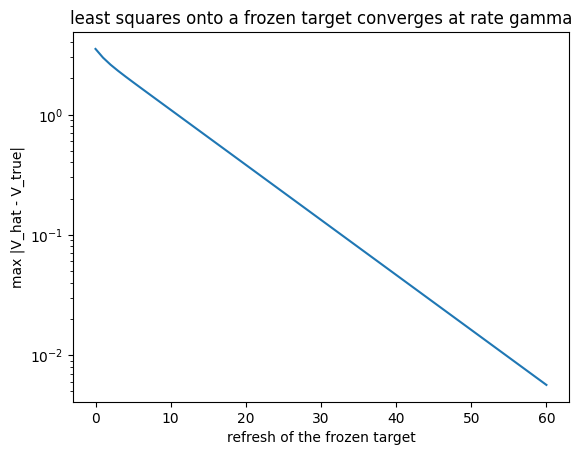

In [5]:
pi = pi_a
V_true, _, _, _ = evaluate(pi)
P_pi = np.einsum("sa,sat->st", pi, P)
r_pi = np.einsum("sa,sa->s", pi, R)

V_hat = np.zeros(3)
frozen_history = [V_hat.copy()]
for _ in range(60):
    target = r_pi + GAMMA * P_pi @ V_hat     # frozen copy supplies the target
    V_hat = target                            # exact least-squares fit, tabular case
    frozen_history.append(V_hat.copy())
frozen_history = np.array(frozen_history)

plt.semilogy(np.abs(frozen_history - V_true).max(axis=1))
plt.xlabel("refresh of the frozen target")
plt.ylabel("max |V_hat - V_true|")
plt.title("least squares onto a frozen target converges at rate gamma");

## 5. The surrogate, and why PPO clips

Freeze the occupancy at the baseline's and the exact identity becomes a
surrogate,

$$L(\pi')=\frac{1}{1-\gamma}\,
  \mathbb E_{s\sim d^{\pi}}\mathbb E_{a\sim\pi'}\big[A^\pi(s,a)\big],$$

which agrees with the truth to first order and diverges from it after that. We
walk along a direction in policy space and plot both, with the region where
every action-probability ratio stays inside $[0.8,1.2]$ shaded.

max |surrogate - true| inside the clip range: 0.0132
gap at the far end: 0.7971


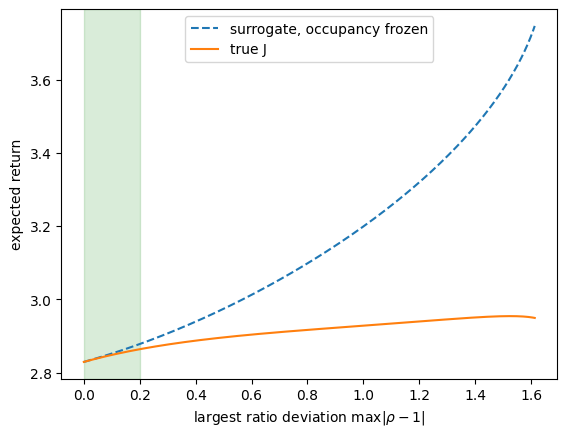

In [6]:
theta_old = theta_a
direction = -np.array([[1.0, -1.0], [-0.6, 0.6], [0.9, -0.9]])
pi_old = softmax_rows(theta_old)
_, _, A_old, J_old = evaluate(pi_old)
d_old = occupancy(pi_old)

steps = np.linspace(0.0, 2.4, 400)
true, surrogate, deviation = [], [], []
for step in steps:
    pi_new = softmax_rows(theta_old + step * direction)
    true.append(evaluate(pi_new)[3])
    surrogate.append(J_old + np.einsum("s,sa,sa->", d_old, pi_new, A_old) / (1 - GAMMA))
    deviation.append(np.abs(pi_new / pi_old - 1).max())
true, surrogate, deviation = map(np.asarray, (true, surrogate, deviation))

inside = deviation <= 0.2
print("max |surrogate - true| inside the clip range:", np.abs(surrogate - true)[inside].max().round(4))
print("gap at the far end:", round(float(surrogate[-1] - true[-1]), 4))

plt.plot(deviation, surrogate, "--", label="surrogate, occupancy frozen")
plt.plot(deviation, true, label="true J")
plt.axvspan(0, 0.2, alpha=0.15, color="green")
plt.xlabel(r"largest ratio deviation $\max|\rho-1|$")
plt.ylabel("expected return")
plt.legend();

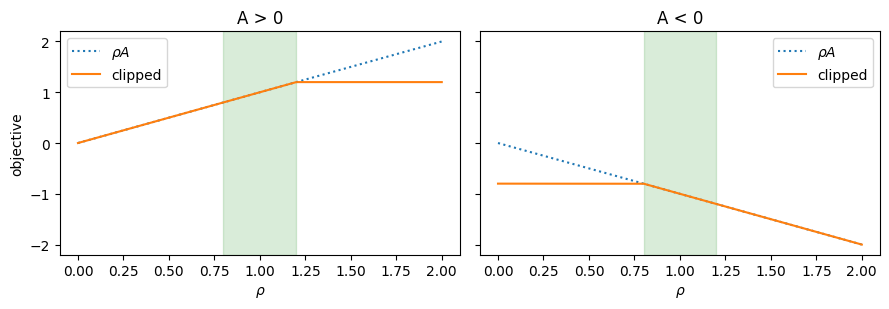

In [7]:
def clipped_term(ratio, advantage, epsilon=0.2):
    return np.minimum(ratio * advantage,
                      np.clip(ratio, 1 - epsilon, 1 + epsilon) * advantage)

ratios = np.linspace(0, 2, 400)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, advantage, title in ((axes[0], 1.0, "A > 0"), (axes[1], -1.0, "A < 0")):
    ax.plot(ratios, ratios * advantage, ":", label=r"$\rho A$")
    ax.plot(ratios, clipped_term(ratios, advantage), label="clipped")
    ax.axvspan(0.8, 1.2, alpha=0.15, color="green")
    ax.set_title(title)
    ax.set_xlabel(r"$\rho$")
    ax.legend()
axes[0].set_ylabel("objective")
plt.tight_layout();

## 6. The three algorithms on a maze

The sections above check identities. This one runs the algorithms.

The environment is a 5x5 maze with walls, one goal, a step cost, and a wall
penalty. The policy is a tabular softmax with one parameter per (state,
action). Nothing is approximated, so any difference between the three learners
below is a property of the *algorithm*, not of a network.

One result to look at honestly: with these settings **actor-critic does worse
than plain REINFORCE**. The one-step residual is a biased advantage estimate
while the critic is still wrong, and on a sparse-reward maze the critic is
wrong for a long time. PPO does best, but it is doing four inner epochs per
batch, so it is also using each episode four times.

In [8]:
WALLS = {(1, 1), (1, 2), (1, 3), (3, 1), (3, 2), (3, 3)}
START, GOAL, SIZE = (0, 0), (4, 4), 5
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # up, down, left, right
N_STATES, N_ACTIONS = SIZE * SIZE, len(MOVES)

def index_of(cell):
    return cell[0] * SIZE + cell[1]

def step(cell, action):
    """Return next cell and reward. Walls and edges cost extra and do not move."""
    row, col = cell[0] + MOVES[action][0], cell[1] + MOVES[action][1]
    if not (0 <= row < SIZE and 0 <= col < SIZE) or (row, col) in WALLS:
        return cell, -0.8
    if (row, col) == GOAL:
        return (row, col), 1.0
    return (row, col), -0.04

print("\n".join("".join("#" if (r, c) in WALLS else
                        "G" if (r, c) == GOAL else
                        "S" if (r, c) == START else "."
                        for c in range(SIZE)) for r in range(SIZE)))

S....
.###.
.....
.###.
....G


In [9]:
def rollout(theta, generator, max_steps=60, gamma=0.99):
    """One episode under the tabular softmax policy. Returns the transitions."""
    pi = softmax_rows(theta)
    cell, episode = START, []
    for _ in range(max_steps):
        s = index_of(cell)
        a = generator.choice(N_ACTIONS, p=pi[s])
        nxt, reward = step(cell, a)
        episode.append((s, a, reward, index_of(nxt)))
        cell = nxt
        if cell == GOAL:
            break
    return episode

def returns_to_go(episode, gamma=0.99):
    out, running = [], 0.0
    for _, _, reward, _ in reversed(episode):
        running = reward + gamma * running
        out.append(running)
    return np.array(out[::-1])

In [10]:
def train(method, episodes=3000, eta=0.25, eta_v=0.15, gamma=0.99,
          epsilon=0.2, inner_epochs=4, seed=7):
    generator = np.random.default_rng(seed)
    theta = np.zeros((N_STATES, N_ACTIONS))
    values = np.zeros(N_STATES)
    curve = np.empty(episodes)

    for episode_index in range(episodes):
        episode = rollout(theta, generator, gamma=gamma)
        curve[episode_index] = sum(r for _, _, r, _ in episode)
        states = np.array([s for s, _, _, _ in episode])
        actions = np.array([a for _, a, _, _ in episode])
        rewards = np.array([r for _, _, r, _ in episode])
        nexts = np.array([n for _, _, _, n in episode])

        if method == "reinforce":
            weights = returns_to_go(episode, gamma) - values[states]
        else:
            # One-step residual against a frozen copy of the critic.
            frozen = values.copy()
            done = np.array([index_of(GOAL) == n for n in nexts])
            weights = rewards + gamma * frozen[nexts] * (~done) - frozen[states]

        pi_old = softmax_rows(theta)
        old_probs = pi_old[states, actions]

        if method == "ppo":
            for _ in range(inner_epochs):
                pi = softmax_rows(theta)
                ratio = pi[states, actions] / old_probs
                # Zero gradient where the clip is active on the improving side.
                active = ~(((ratio > 1 + epsilon) & (weights > 0)) |
                           ((ratio < 1 - epsilon) & (weights < 0)))
                grad = np.zeros_like(theta)
                coef = ratio * weights * active
                for s, a, c in zip(states, actions, coef):
                    grad[s] -= c * pi[s]
                    grad[s, a] += c
                theta = theta + eta * grad / len(states)
        else:
            pi = softmax_rows(theta)
            grad = np.zeros_like(theta)
            for s, a, w in zip(states, actions, weights):
                grad[s] -= w * pi[s]
                grad[s, a] += w
            theta = theta + eta * grad / len(states)

        if method != "reinforce":
            target = rewards + gamma * values[nexts] * ~np.array(
                [index_of(GOAL) == n for n in nexts])
            values[states] += eta_v * (target - values[states])

    return curve, theta

curves = {name: train(name)[0] for name in ("reinforce", "actor-critic", "ppo")}
print({name: round(curve[-200:].mean(), 3) for name, curve in curves.items()})

{'reinforce': np.float64(0.628), 'actor-critic': np.float64(0.357), 'ppo': np.float64(0.684)}


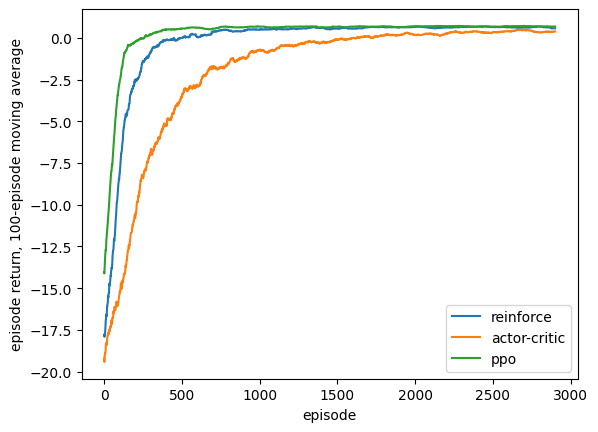

In [11]:
def smooth(values, window=100):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

for name, curve in curves.items():
    plt.plot(smooth(curve), label=name)
plt.xlabel("episode")
plt.ylabel("episode return, 100-episode moving average")
plt.legend();

In [12]:
_, theta_ppo = train("ppo", episodes=3000)
arrows = "^v<>"
rows = []
for r in range(SIZE):
    row = ""
    for c in range(SIZE):
        if (r, c) in WALLS:
            row += "#"
        elif (r, c) == GOAL:
            row += "G"
        else:
            row += arrows[int(np.argmax(theta_ppo[index_of((r, c))]))]
    rows.append(row)
print("the greedy policy PPO ends up with:")
print("\n".join(rows))

the greedy policy PPO ends up with:
>>>>v
^###v
>>>>v
v###v
>>>>G


## Try It

1. In section 2, make the two policies as different as you like. Does the
   error in the lemma ever grow? Then replace `occupancy(pi_cand)` by
   `occupancy(pi_base)` and repeat --- how far apart can the policies get
   before the identity fails by more than $0.01$?
2. In section 3, raise `epsilon` in `numerical_gradient` to $10^{-2}$. Which of
   the two calculations is now the inaccurate one, and why?
3. In section 4, replace the frozen target by one recomputed from `V_hat`
   inside a gradient step on the same loss. What changes about the convergence
   plot?
4. In section 5, shrink `direction` by a factor of ten. Where does the shaded
   clip region now sit relative to the point where the surrogate and the truth
   part company?
5. In section 6, raise `eta_v` so the critic learns faster. At what point does
   actor-critic overtake REINFORCE, and what does that tell you about where its
   bias comes from?
6. Set `inner_epochs=1` for PPO. It should now behave like the actor-critic
   run. Does it? If not, which of the two remaining differences --- the ratio
   or the clip --- explains the gap?